# Case 3: does the fitted root-N score vanish?
**Run All** reads the existing CSV and saves two PNGs in `run_psi_n_if/figures/`. No fitting, simulation, or PDFs.

For coordinates $j=1,2$, this plots the saved Adam scores
$$S_{N,j}=\left[\sqrt{N}\,\Psi_N(\widehat\zeta,\widehat h)\right]_j
=-\frac1{\sqrt{N}}\sum_{i\in\mathcal I_{\rm train}}
\{\tau-\mathbf1(\widehat r_i<0)\}\widetilde X_{ij},$$
where $\widehat\zeta=\widehat\theta-(1,-1)^\top$, $\widetilde X=X-E[X\mid Z]$,
$\widehat h=\widehat m-m_0+\varphi^{*\top}\widehat\zeta$, and
$\widehat r=Y-X^\top\widehat\theta-\widehat m$; $\varphi^*(Z)=E[X\mid Z]$, $\tau=0.5$.
Here $N=n_{\rm train}=0.8n$; the horizontal axis is total generated $n$.
The CSV columns `adam_sn_psi_fit_1/2` are **already scaled by $\sqrt{N}$**.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

EPOCHS = 1000
THRESHOLDS = (0.02, 0.05, 0.10)
rel = Path('results/2026-09-11_asymptotic_normality_case3')
candidates = [p / suffix for p in [Path.cwd(), *Path.cwd().parents]
              for suffix in (Path('.'), rel)]
BASE = next((p for p in candidates
             if (p / 'run_psi_n_if/replication_terms.csv').is_file()), None)
if BASE is None:
    raise FileNotFoundError('Open from the Case 3 folder or the dplqr repository.')
SOURCE = BASE / 'run_psi_n_if/replication_terms.csv'
FIG_DIR = BASE / 'run_psi_n_if/figures'
df = pd.read_csv(SOURCE)
df = df.loc[df.epochs == EPOCHS].copy()
score_columns = ['adam_sn_psi_fit_1', 'adam_sn_psi_fit_2']
if df.empty or df.duplicated(['n', 'rep']).any():
    raise ValueError('Missing epoch results or duplicate replications.')
if not np.isfinite(df[score_columns].to_numpy()).all():
    raise ValueError('Saved scores contain nonfinite values.')
print('Source:', SOURCE.resolve())
display(df.groupby('n').agg(N=('n_train', 'first'), Q=('rep', 'size')))


Source: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3\run_psi_n_if\replication_terms.csv


,N,Q
n,,
500,400,200
1000,800,200
2000,1600,200
4000,3200,200


In [2]:
rows = []
for j in (1, 2):
    for n, g in df.groupby('n', sort=True):
        s = g[f'adam_sn_psi_fit_{j}'].to_numpy()
        a = np.abs(s)
        rows.append(dict(component=j, n=n, N=int(g.n_train.iloc[0]), Q=len(s),
                         signed_mean=s.mean(), mean_abs=a.mean(),
                         MCSE=a.std(ddof=1)/np.sqrt(len(s)) if len(s) > 1 else np.nan,
                         RMS=np.sqrt(np.mean(s*s)),
                         **{f'P_gt_{e:g}': np.mean(a > e) for e in THRESHOLDS}))
summary = pd.DataFrame(rows)
display(summary.round(4))


,component,n,N,Q,signed_mean,mean_abs,MCSE,RMS,P_gt_0.02,P_gt_0.05,P_gt_0.1
0,1,500,400,200,0.0025,0.1640,0.0087,0.2047,0.940,0.825,0.620
1,1,1000,800,200,-0.0259,0.1602,0.0083,0.1986,0.950,0.805,0.625
2,1,2000,1600,200,-0.0216,0.1574,0.0085,0.1983,0.935,0.805,0.625
3,1,4000,3200,200,-0.0185,0.1647,0.0092,0.2095,0.880,0.775,0.600
4,2,500,400,200,0.0396,0.1628,0.0086,0.2029,0.935,0.815,0.640
5,2,1000,800,200,0.0195,0.1636,0.0089,0.2067,0.920,0.775,0.615
6,2,2000,1600,200,0.0015,0.1621,0.0086,0.2027,0.930,0.830,0.640
7,2,4000,3200,200,-0.0129,0.1588,0.0090,0.2032,0.880,0.730,0.605


Saved: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3\run_psi_n_if\figures\adam_sqrt_N_Psi_fit_1.png


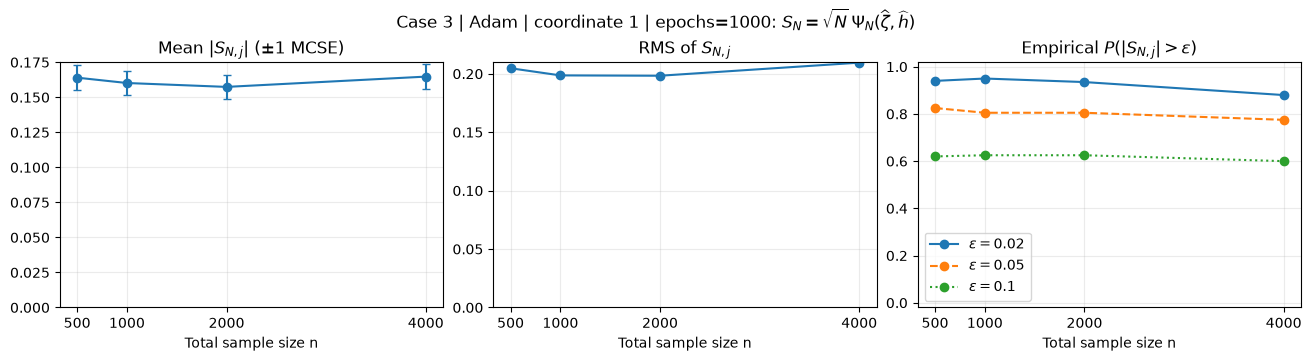

Saved: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3\run_psi_n_if\figures\adam_sqrt_N_Psi_fit_2.png


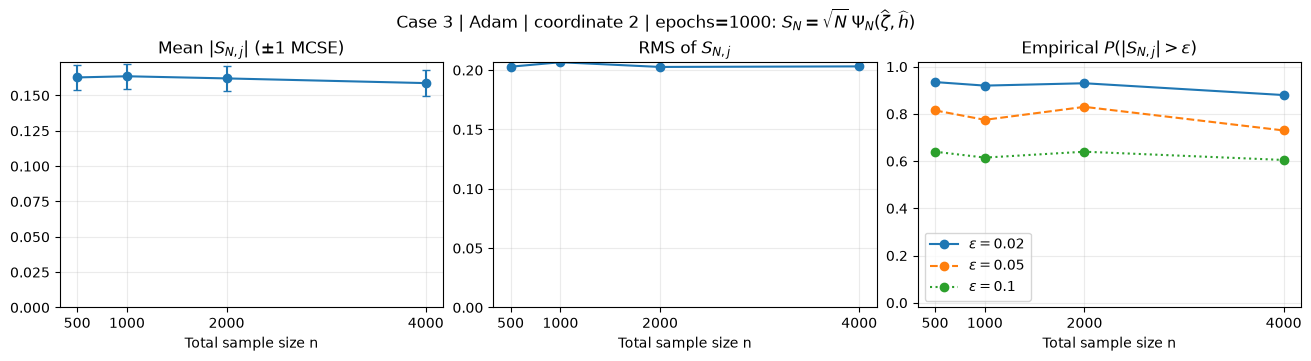

In [3]:
FIG_DIR.mkdir(parents=True, exist_ok=True)
for j in (1, 2):
    g = summary.loc[summary.component == j].sort_values('n')
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)
    axes[0].errorbar(g.n, g.mean_abs, yerr=g.MCSE, marker='o', capsize=3)
    axes[1].plot(g.n, g.RMS, 'o-')
    for e, style in zip(THRESHOLDS, ('-', '--', ':')):
        axes[2].plot(g.n, g[f'P_gt_{e:g}'], marker='o', linestyle=style,
                     label=rf'$\epsilon={e:g}$')
    titles = [r'Mean $|S_{N,j}|$ ($\pm1$ MCSE)', r'RMS of $S_{N,j}$',
              r'Empirical $P(|S_{N,j}|>\epsilon)$']
    for ax, title in zip(axes, titles):
        ax.set(title=title, xlabel='Total sample size n', xticks=g.n.tolist())
        ax.set_ylim(bottom=0)
        ax.grid(alpha=.25)
    axes[2].set_ylim(-.02, 1.02)
    axes[2].legend()
    fig.suptitle(f'Case 3 | Adam | coordinate {j} | epochs={EPOCHS}'
                 + r': $S_N=\sqrt{N}\,\Psi_N(\widehat{\zeta},\widehat{h})$')
    target = FIG_DIR / f'adam_sqrt_N_Psi_fit_{j}.png'
    fig.savefig(target, dpi=200, bbox_inches='tight')
    print('Saved:', target.resolve())
    plt.show()
    plt.close(fig)


**Interpretation:** $S_{N,j}=o_p(1)$ requires $P(|S_{N,j}|>\epsilon)\to0$ for every fixed $\epsilon>0$. The left and middle panels show magnitude without signed cancellation; the right panel checks exceedance probabilities at three fixed thresholds. Flat magnitudes and substantial tail probabilities give no evidence of vanishing over this sample-size range, but cannot prove asymptotic nonconvergence. These are fitted empirical scores, not coefficient bias or population scores. Error bars are one Monte Carlo standard error, not 95% intervals.